## 0. Setup and Imports

In [1]:

!pip -q install tensorflow scikit-learn matplotlib seaborn requests tqdm

import os, time, zipfile, io, requests, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Download UCI HAR Raw Inertial Signals Dataset

In [2]:

DATA_DIR = "/content/har_data"
os.makedirs(DATA_DIR, exist_ok=True)

url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
zip_path = os.path.join(DATA_DIR, "har.zip")

if not os.path.exists(os.path.join(DATA_DIR, "UCI HAR Dataset")):
    r = requests.get(url, timeout=120)
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    # the inner file is itself a zip in some mirrors
    inner_zip = os.path.join(DATA_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner_zip):
        with zipfile.ZipFile(inner_zip, "r") as z:
            z.extractall(DATA_DIR)

HAR_ROOT = os.path.join(DATA_DIR, "UCI HAR Dataset")
print("Contents:", os.listdir(HAR_ROOT))


Contents: ['README.txt', 'features.txt', 'train', 'features_info.txt', 'activity_labels.txt', 'test', '.DS_Store']


## 2. Load Raw Inertial Signals (128 x 9 windows)

In [3]:

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(subset):
    # subset = "train" or "test"
    data = []
    for sig in SIGNALS:
        path = os.path.join(HAR_ROOT, subset, "Inertial Signals", f"{sig}_{subset}.txt")
        arr = np.loadtxt(path)
        data.append(arr)
    # each arr: (N, 128) -> stack along last axis -> (N, 128, 9)
    X = np.stack(data, axis=-1)
    return X

def load_labels(subset):
    path = os.path.join(HAR_ROOT, subset, f"y_{subset}.txt")
    y = np.loadtxt(path).astype(int) - 1  # labels are 1..6 -> 0..5
    return y

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full = load_signals("test")
y_test_full = load_labels("test")

ACTIVITY_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
                  "SITTING", "STANDING", "LAYING"]

print("Full train:", X_train_full.shape, y_train_full.shape)
print("Full test :", X_test_full.shape, y_test_full.shape)


Full train: (7352, 128, 9) (7352,)
Full test : (2947, 128, 9) (2947,)


## 3. Preprocessing — Subset, Normalize, Split, Verify Class Balance

In [4]:

# Recommended laboratory subset: 1500-3000 training windows, balanced classes
N_SUBSET = 3000

rng = np.random.RandomState(SEED)
idx = rng.permutation(len(X_train_full))[:N_SUBSET]
X_sub = X_train_full[idx]
y_sub = y_train_full[idx]

# Train / val split from the subset (70/15), test set kept separate (official UCI test partition, trimmed for speed)
X_train, X_val, y_train, y_val = train_test_split(
    X_sub, y_sub, test_size=0.1765, stratify=y_sub, random_state=SEED  # 0.1765*0.85≈0.15 of original
)
# proportion check -> aim for ~70/15 train/val out of the subset
N_TEST = min(700, len(X_test_full))
test_idx = rng.permutation(len(X_test_full))[:N_TEST]
X_test = X_test_full[test_idx]
y_test = y_test_full[test_idx]

# Normalize using TRAIN statistics only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mean) / std
X_val_n = (X_val - mean) / std
X_test_n = (X_test - mean) / std

print("Input tensor shape:")
print(f"Training   : {X_train_n.shape}")
print(f"Validation : {X_val_n.shape}")
print(f"Testing    : {X_test_n.shape}")
print(f"Number of classes: {len(ACTIVITY_NAMES)}")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")

print("\nClass distribution (train):")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution (val):")
print(pd.Series(y_val).value_counts().sort_index())
print("\nClass distribution (test):")
print(pd.Series(y_test).value_counts().sort_index())


Input tensor shape:
Training   : (2470, 128, 9)
Validation : (530, 128, 9)
Testing    : (700, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train):
0    408
1    338
2    348
3    438
4    456
5    482
Name: count, dtype: int64

Class distribution (val):
0     87
1     73
2     75
3     94
4     98
5    103
Name: count, dtype: int64

Class distribution (test):
0    113
1    111
2    105
3    121
4    129
5    121
Name: count, dtype: int64


## 4. Temporal Data Visualization (Plot 1)

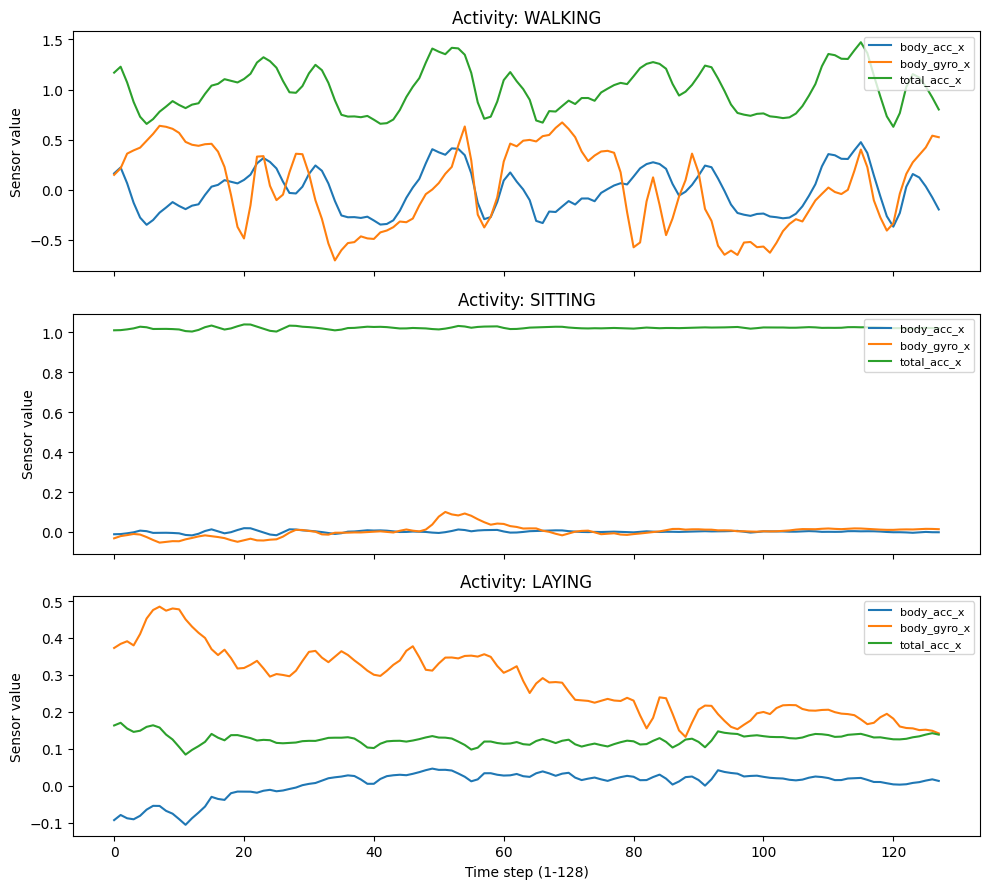

In [5]:

channel_names = SIGNALS
sample_classes = [0, 3, 5]  # WALKING, SITTING, LAYING as representative examples

fig, axes = plt.subplots(len(sample_classes), 1, figsize=(10, 9), sharex=True)
for ax, cls in zip(axes, sample_classes):
    sample_idx = np.where(y_train == cls)[0][0]
    seq = X_train[sample_idx]
    for ch in [0, 3, 6]:  # one accel, one gyro, one total-accel channel
        ax.plot(range(128), seq[:, ch], label=channel_names[ch])
    ax.set_title(f"Activity: {ACTIVITY_NAMES[cls]}")
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
plt.tight_layout()
plt.savefig("plot1_temporal_signals.png", dpi=150)
plt.show()


## 5. Numerical BPTT Exercise (Manual vs Programmatic)

In [6]:

x = [0.5, 0.7, 0.2]
h0, Wx, Wh, b = 0.0, 0.5, 0.8, 0.1

h = h0
manual_h = []
for xt in x:
    h = np.tanh(Wx * xt + Wh * h + b)
    manual_h.append(h)

print("Manually computed hidden states:")
for t, val in enumerate(manual_h, 1):
    print(f"h{t} = {val:.6f}")

# Programmatic check using a tiny TF RNNCell with matching weights
cell = tf.keras.layers.SimpleRNNCell(1, activation="tanh")
cell.build(input_shape=(None, 1))
cell.set_weights([np.array([[Wx]], dtype=np.float32),
                   np.array([[Wh]], dtype=np.float32),
                   np.array([b], dtype=np.float32)])

state = tf.zeros((1, 1))
prog_h = []
for xt in x:
    out, [state] = cell(tf.constant([[xt]], dtype=tf.float32), [state])
    prog_h.append(float(out.numpy()[0, 0]))

print("\nProgrammatically computed hidden states:")
for t, val in enumerate(prog_h, 1):
    print(f"h{t} = {val:.6f}")


Manually computed hidden states:
h1 = 0.336376
h2 = 0.616352
h3 = 0.599958

Programmatically computed hidden states:
h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


## 6. Model Builder and Common Training Configuration

In [7]:

INPUT_SHAPE = (X_train_n.shape[1], X_train_n.shape[2])
NUM_CLASSES = len(ACTIVITY_NAMES)

def build_model(recurrent_type="SimpleRNN", units=32, input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inp = Input(shape=input_shape)
    if recurrent_type == "SimpleRNN":
        x = layers.SimpleRNN(units)(inp)
    elif recurrent_type == "LSTM":
        x = layers.LSTM(units)(inp)
    elif recurrent_type == "GRU":
        x = layers.GRU(units)(inp)
    else:
        raise ValueError(recurrent_type)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

EPOCHS = 30
BATCH_SIZE = 32

def train_model(recurrent_type, units=32, epochs=EPOCHS, X_tr=X_train_n, y_tr=y_train,
                 X_v=X_val_n, y_v=y_val, verbose=0):
    tf.random.set_seed(SEED)
    model = build_model(recurrent_type, units=units, input_shape=(X_tr.shape[1], X_tr.shape[2]))
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=BATCH_SIZE, verbose=verbose)
    train_time = time.time() - start
    return model, history, train_time

print("Model builder ready. Input shape:", INPUT_SHAPE)


Model builder ready. Input shape: (128, 9)


## 7. Train Vanilla RNN

In [8]:

rnn_model, rnn_history, rnn_time = train_model("SimpleRNN", verbose=1)
print(f"RNN training time: {rnn_time:.2f} s")
rnn_model.summary()


Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.4413 - loss: 1.3901 - val_accuracy: 0.5302 - val_loss: 1.1599
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5947 - loss: 1.0368 - val_accuracy: 0.6094 - val_loss: 0.9572
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5883 - loss: 0.9574 - val_accuracy: 0.6547 - val_loss: 0.8504
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6073 - loss: 0.9357 - val_accuracy: 0.6679 - val_loss: 0.9397
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6530 - loss: 0.8378 - val_accuracy: 0.6830 - val_loss: 0.6904
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6777 - loss: 0.7239 - val_accuracy: 0.6830 - val_loss: 0.6690
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6826 - loss: 0.7355 - val_accuracy: 0.6377 - val_loss: 0.8829
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6960 - loss: 0.6910 - val_accuracy: 0.7075 - v

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924 (23.14 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,950 (15.43 KB)

## 8. Train LSTM

In [9]:

lstm_model, lstm_history, lstm_time = train_model("LSTM", verbose=1)
print(f"LSTM training time: {lstm_time:.2f} s")
lstm_model.summary()


Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4818 - loss: 1.4498 - val_accuracy: 0.5642 - val_loss: 1.1200
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6425 - loss: 0.9018 - val_accuracy: 0.6925 - val_loss: 0.7277
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7101 - loss: 0.6700 - val_accuracy: 0.7566 - val_loss: 0.6049
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7842 - loss: 0.5547 - val_accuracy: 0.8283 - val_loss: 0.5355
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8377 - loss: 0.4621 - val_accuracy: 0.8925 - val_loss: 0.4081
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8850 - loss: 0.3435 - val_accuracy: 0.9302 - val_loss: 0.2963
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9259 - loss: 0.2610 - val_accuracy: 0.9358 - val_loss: 0.2296
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9296 - loss: 0.2310 - val_accuracy: 0.9283 - v

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,020 (70.39 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,014 (46.93 KB)

## 9. Train GRU

In [10]:

gru_model, gru_history, gru_time = train_model("GRU", verbose=1)
print(f"GRU training time: {gru_time:.2f} s")
gru_model.summary()


Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4138 - loss: 1.5198 - val_accuracy: 0.5868 - val_loss: 1.3047
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6223 - loss: 1.1206 - val_accuracy: 0.6358 - val_loss: 0.8855
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6988 - loss: 0.7132 - val_accuracy: 0.7321 - val_loss: 0.5977
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7575 - loss: 0.5773 - val_accuracy: 0.8264 - val_loss: 0.5024
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8239 - loss: 0.4867 - val_accuracy: 0.8868 - val_loss: 0.3972
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8656 - loss: 0.3792 - val_accuracy: 0.9321 - val_loss: 0.2837
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9113 - loss: 0.2755 - val_accuracy: 0.9434 - val_loss: 0.2039
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9348 - loss: 0.1980 - val_accuracy: 0.9509 - v

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,276 (55.77 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,518 (37.18 KB)

## 10. Training and Validation Curves (Plots 2 & 3)

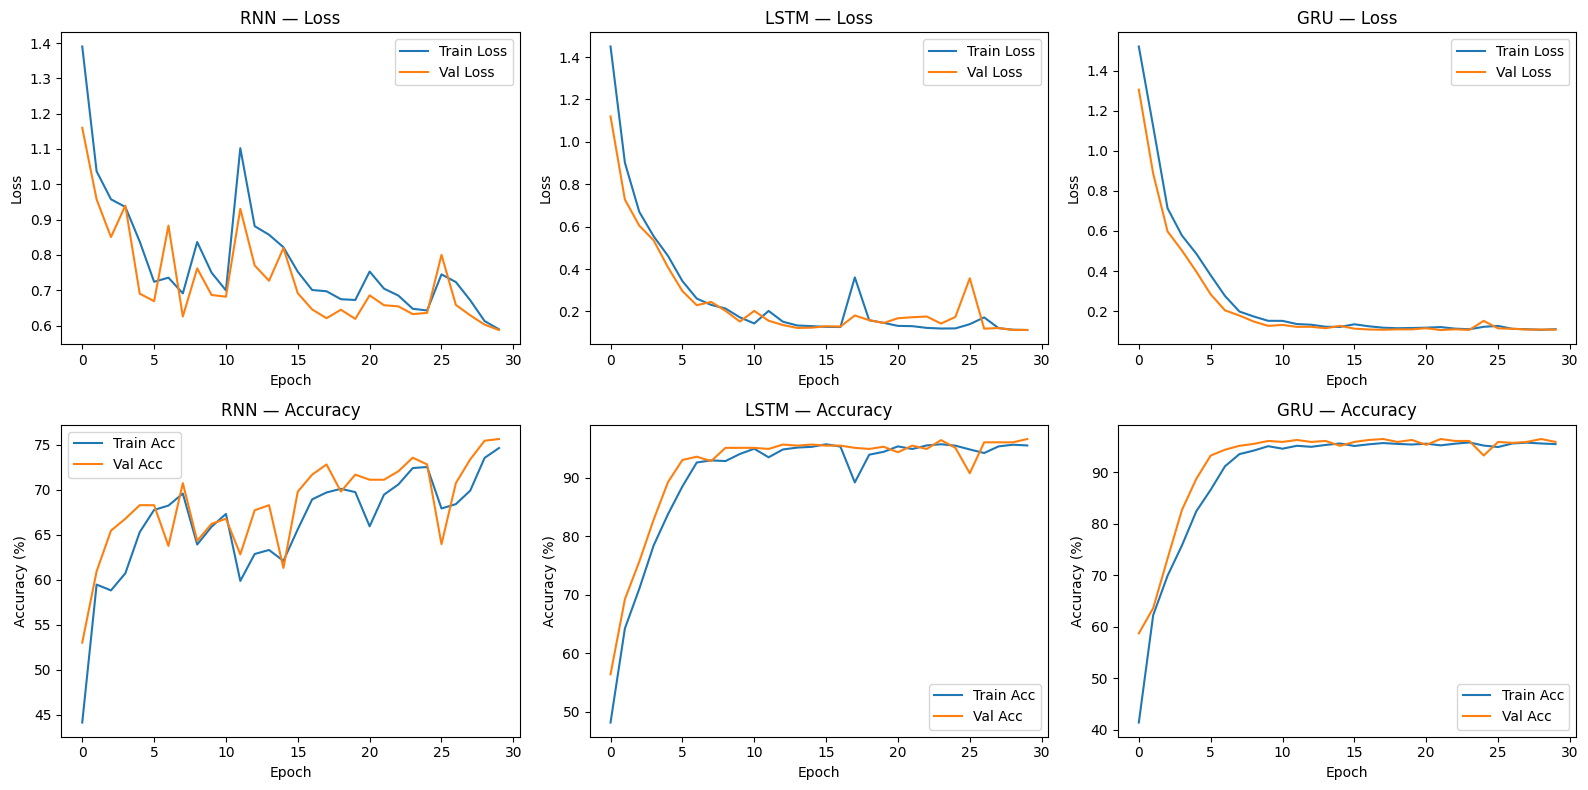

In [11]:

histories = {"RNN": rnn_history, "LSTM": lstm_history, "GRU": gru_history}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (name, hist) in enumerate(histories.items()):
    axes[0, i].plot(hist.history["loss"], label="Train Loss")
    axes[0, i].plot(hist.history["val_loss"], label="Val Loss")
    axes[0, i].set_title(f"{name} — Loss")
    axes[0, i].set_xlabel("Epoch"); axes[0, i].set_ylabel("Loss"); axes[0, i].legend()

    axes[1, i].plot(np.array(hist.history["accuracy"]) * 100, label="Train Acc")
    axes[1, i].plot(np.array(hist.history["val_accuracy"]) * 100, label="Val Acc")
    axes[1, i].set_title(f"{name} — Accuracy")
    axes[1, i].set_xlabel("Epoch"); axes[1, i].set_ylabel("Accuracy (%)"); axes[1, i].legend()

plt.tight_layout()
plt.savefig("plot2_3_training_curves.png", dpi=150)
plt.show()


## 11. Performance Evaluation on Test Set

In [12]:

def evaluate_model(model, X_te=X_test_n, y_te=y_test, name=""):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_te, y_pred) * 100
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(y_te, y_pred, average="macro", zero_division=0) * 100
    f1 = f1_score(y_te, y_pred, average="macro", zero_division=0) * 100
    params = model.count_params()

    return {
        "y_pred": y_pred,
        "Accuracy (%)": acc,
        "Macro Precision (%)": prec,
        "Macro Recall (%)": rec,
        "Macro F1 (%)": f1,
        "Parameters": params,
    }

rnn_eval = evaluate_model(rnn_model, name="RNN")
lstm_eval = evaluate_model(lstm_model, name="LSTM")
gru_eval = evaluate_model(gru_model, name="GRU")

results_table = pd.DataFrame({
    "RNN": {**{k: v for k, v in rnn_eval.items() if k != "y_pred"}, "Training Time (s)": rnn_time},
    "LSTM": {**{k: v for k, v in lstm_eval.items() if k != "y_pred"}, "Training Time (s)": lstm_time},
    "GRU": {**{k: v for k, v in gru_eval.items() if k != "y_pred"}, "Training Time (s)": gru_time},
}).T
print(results_table.round(2))


      Accuracy (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  \
RNN          66.86                66.30             65.91         65.04   
LSTM         87.86                88.23             88.26         88.20   
GRU          88.86                88.97             89.22         88.99   

      Parameters  Training Time (s)  
RNN       1974.0              32.38  
LSTM      6006.0              32.50  
GRU       4758.0              27.59  


## 12. Confusion Matrices (Plot 4)

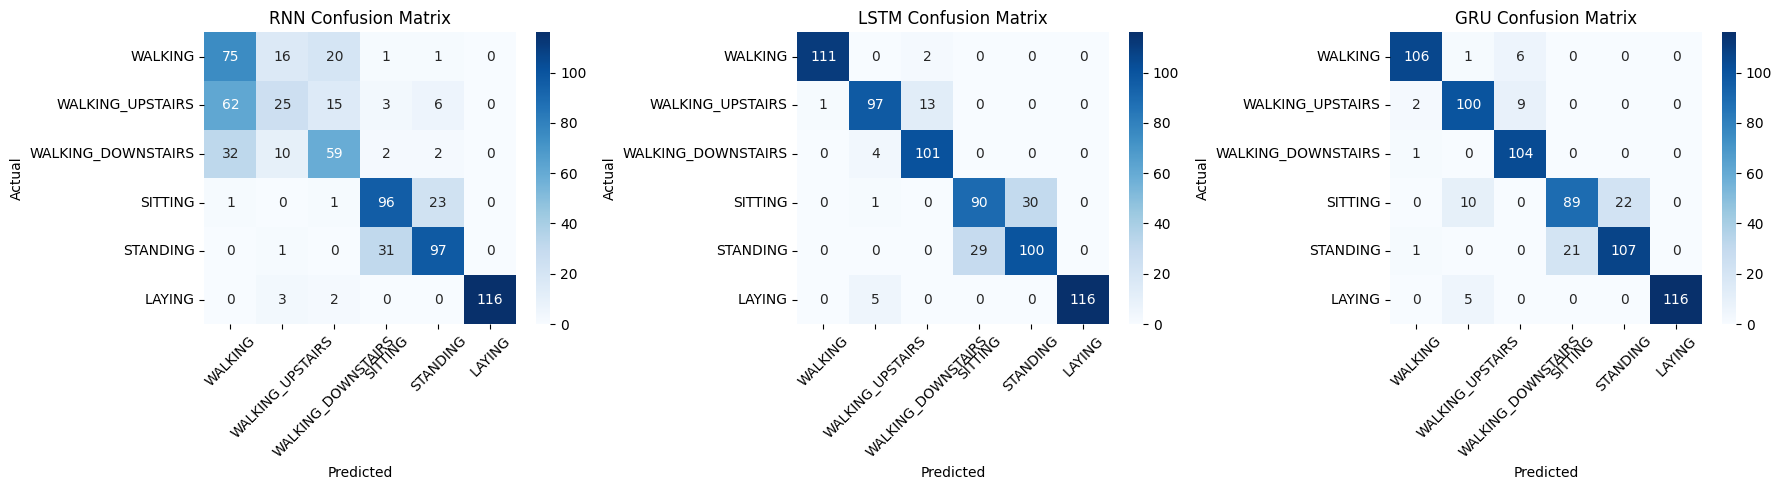

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, ev) in zip(axes, [("RNN", rnn_eval), ("LSTM", lstm_eval), ("GRU", gru_eval)]):
    cm = confusion_matrix(y_test, ev["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("plot4_confusion_matrices.png", dpi=150)
plt.show()


## 13. RNN vs LSTM vs GRU Comparison Table and Bar Plot (Plot 5)

      Parameters  Training time (s)  Test F1-score (%)
RNN       1974.0              32.38              65.04
LSTM      6006.0              32.50              88.20
GRU       4758.0              27.59              88.99


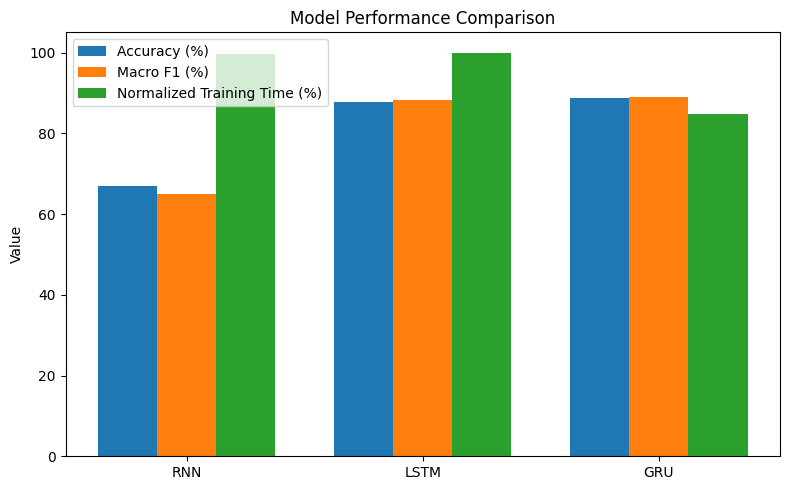

In [14]:

comparison = pd.DataFrame({
    "RNN": {"Parameters": rnn_eval["Parameters"], "Training time (s)": round(rnn_time, 2),
            "Test F1-score (%)": round(rnn_eval["Macro F1 (%)"], 2)},
    "LSTM": {"Parameters": lstm_eval["Parameters"], "Training time (s)": round(lstm_time, 2),
             "Test F1-score (%)": round(lstm_eval["Macro F1 (%)"], 2)},
    "GRU": {"Parameters": gru_eval["Parameters"], "Training time (s)": round(gru_time, 2),
            "Test F1-score (%)": round(gru_eval["Macro F1 (%)"], 2)},
}).T
print(comparison)

# Bar plot: Accuracy, Macro F1, and normalized training time
models_names = ["RNN", "LSTM", "GRU"]
acc_vals = [rnn_eval["Accuracy (%)"], lstm_eval["Accuracy (%)"], gru_eval["Accuracy (%)"]]
f1_vals = [rnn_eval["Macro F1 (%)"], lstm_eval["Macro F1 (%)"], gru_eval["Macro F1 (%)"]]
time_vals = [rnn_time, lstm_time, gru_time]
time_norm = [100 * t / max(time_vals) for t in time_vals]

x = np.arange(len(models_names))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, acc_vals, width, label="Accuracy (%)")
ax.bar(x, f1_vals, width, label="Macro F1 (%)")
ax.bar(x + width, time_norm, width, label="Normalized Training Time (%)")
ax.set_xticks(x); ax.set_xticklabels(models_names)
ax.set_ylabel("Value"); ax.set_title("Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plot5_model_comparison.png", dpi=150)
plt.show()


## 14. Effect of Sequence Length (Plot 6)

T= 32  RNN    F1=65.31%
T= 32  LSTM   F1=84.47%
T= 32  GRU    F1=83.29%
T= 64  RNN    F1=67.42%
T= 64  LSTM   F1=87.69%
T= 64  GRU    F1=87.48%
T=128  RNN    F1=60.99%
T=128  LSTM   F1=88.41%
T=128  GRU    F1=89.34%

                    RNN   LSTM    GRU
Sequence Length                     
32               65.31  84.47  83.29
64               67.42  87.69  87.48
128              60.99  88.41  89.34


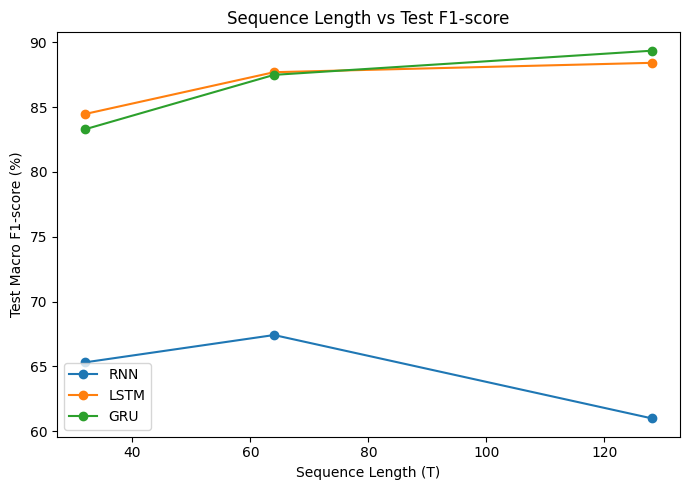

In [15]:

def truncate_sequences(X, T):
    # keep the first T time steps
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_results = {"RNN": [], "LSTM": [], "GRU": []}

for T in seq_lengths:
    Xtr_T = truncate_sequences(X_train_n, T)
    Xv_T = truncate_sequences(X_val_n, T)
    Xte_T = truncate_sequences(X_test_n, T)

    for rtype in ["SimpleRNN", "LSTM", "GRU"]:
        key = "RNN" if rtype == "SimpleRNN" else rtype
        m, h, t_time = train_model(rtype, units=32, epochs=15,
                                    X_tr=Xtr_T, y_tr=y_train, X_v=Xv_T, y_v=y_val, verbose=0)
        ev = evaluate_model(m, X_te=Xte_T, y_te=y_test)
        seqlen_results[key].append(ev["Macro F1 (%)"])
        print(f"T={T:3d}  {key:5s}  F1={ev['Macro F1 (%)']:.2f}%")

seqlen_df = pd.DataFrame(seqlen_results, index=seq_lengths)
seqlen_df.index.name = "Sequence Length"
print("\n", seqlen_df.round(2))

plt.figure(figsize=(7, 5))
for col in seqlen_df.columns:
    plt.plot(seqlen_df.index, seqlen_df[col], marker="o", label=col)
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Sequence Length vs Test F1-score")
plt.legend()
plt.tight_layout()
plt.savefig("plot6_seqlen_vs_f1.png", dpi=150)
plt.show()


15. Video Understanding — Download a Small UCF101 Subset

In [23]:
!pip -q install remotezip  # (no longer needed, but harmless if already installed)

import cv2
import pandas as pd
import shutil

UCF_DIR = "/content/ucf_subset"
os.makedirs(UCF_DIR, exist_ok=True)

# Reliable source: pre-curated 5-class UCF101 subset hosted as a GitHub Release asset
# (used by the official Keras "Video Classification with a CNN-RNN" tutorial)
ARCHIVE_URL = ("https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/"
               "releases/download/v1.0.0/ucf101_top5.tar.gz")

!wget -q {ARCHIVE_URL} -O /content/ucf101_top5.tar.gz
!tar xf /content/ucf101_top5.tar.gz -C /content

# This archive extracts train.csv, test.csv, and train/ + test/ folders of .avi files,
# each row mapping a video_name to its class ("tag").
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")
all_df = pd.concat([train_df.assign(split="train"), test_df.assign(split="test")], ignore_index=True)

print("Classes available:", sorted(all_df["tag"].unique()))
print(f"Total videos: {len(all_df)} ({len(train_df)} train, {len(test_df)} test)")

CLASSES = ["Punch", "TennisSwing", "PlayingCello"]  # pick any subset of the 5 available classes
VIDEOS_PER_CLASS = 8

rng = random.Random(SEED)
for c in CLASSES:
    os.makedirs(os.path.join(UCF_DIR, c), exist_ok=True)
    class_rows = all_df[all_df["tag"] == c].to_dict("records")
    if not class_rows:
        print(f"WARNING: class '{c}' not found — check spelling against the list above.")
        continue
    rng.shuffle(class_rows)
    for row in class_rows[:VIDEOS_PER_CLASS]:
        src = os.path.join("/content", row["split"], row["video_name"])
        dst = os.path.join(UCF_DIR, c, row["video_name"])
        if os.path.exists(src):
            shutil.copy(src, dst)

for c in CLASSES:
    n_files = len([f for f in os.listdir(os.path.join(UCF_DIR, c)) if f.endswith(".avi")])
    print(f"{c}: {n_files} video files found")

Classes available: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']
Total videos: 818 (594 train, 224 test)
Punch: 8 video files found
TennisSwing: 8 video files found
PlayingCello: 8 video files found


## 16. Frame Extraction and CNN (MobileNetV2) Feature Extraction

In [24]:

NUM_FRAMES = 10
IMG_SIZE = 224

def sample_frames(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    indices = np.linspace(0, max(total - 1, 0), num_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
    cap.release()
    if len(frames) < num_frames:
        return None
    return np.stack(frames[:num_frames])  # (10, 224, 224, 3)

cnn_base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet", pooling="avg"
)
cnn_base.trainable = False  # freeze — feature extractor only

def extract_video_features(frames):
    # frames: (10, 224, 224, 3), uint8
    x = tf.keras.applications.mobilenet_v2.preprocess_input(frames.astype(np.float32))
    feats = cnn_base(x, training=False).numpy()  # (10, D)
    return feats

FEATURE_DIM = cnn_base.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

video_paths, video_labels = [], []
for label_idx, c in enumerate(CLASSES):
    class_dir = os.path.join(UCF_DIR, c)
    for f in sorted(os.listdir(class_dir))[:VIDEOS_PER_CLASS]:
        if f.lower().endswith((".avi", ".mp4")):
            video_paths.append(os.path.join(class_dir, f))
            video_labels.append(label_idx)

print(f"Found {len(video_paths)} videos across {len(CLASSES)} classes")

X_video_feats, y_video = [], []
for path, label in zip(video_paths, video_labels):
    frames = sample_frames(path)
    if frames is None:
        continue
    feats = extract_video_features(frames)
    X_video_feats.append(feats)
    y_video.append(label)

if len(X_video_feats) > 0:
    X_video_feats = np.stack(X_video_feats)  # (B, 10, D)
    y_video = np.array(y_video)
    print("Video feature tensor shape:", X_video_feats.shape)
else:
    print("No videos were processed — add .avi/.mp4 files under /content/ucf_subset/<class>/ and re-run.")


CNN feature dimension D = 1280
Found 24 videos across 3 classes
Video feature tensor shape: (24, 10, 1280)


## 17. Plot 7 — Sample Frames from One Video

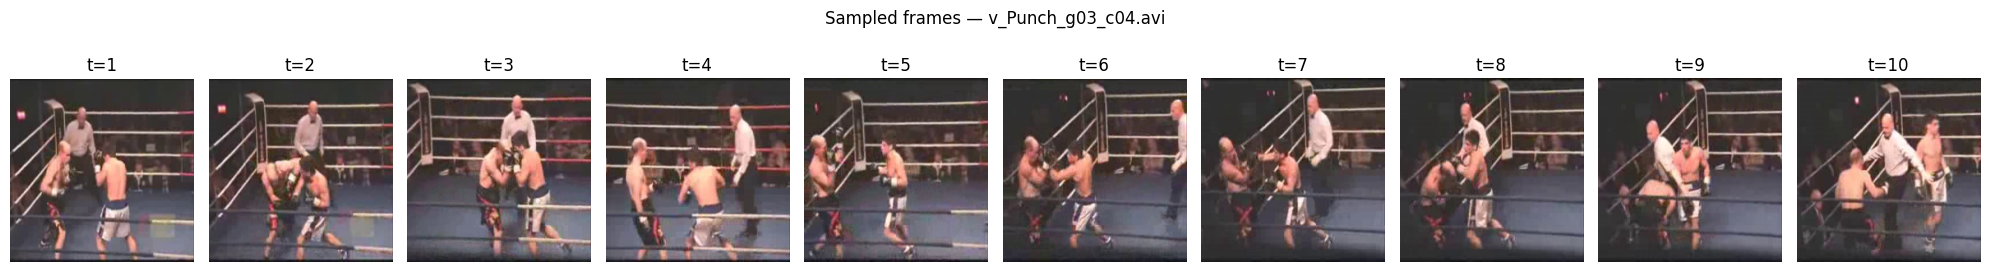

In [25]:

if len(video_paths) > 0:
    sample_path = video_paths[0]
    frames = sample_frames(sample_path)
    fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(20, 3))
    for i, ax in enumerate(axes):
        ax.imshow(frames[i])
        ax.set_title(f"t={i+1}")
        ax.axis("off")
    plt.suptitle(f"Sampled frames — {os.path.basename(sample_path)}")
    plt.tight_layout()
    plt.savefig("plot7_video_frames.png", dpi=150)
    plt.show()
else:
    print("Skipped — no videos available yet.")


## 18. CNN–LSTM / CNN–GRU Model: Build, Train and Evaluate

In [26]:

if len(X_video_feats) >= 6:  # need enough samples for a train/val/test split
    Xv_tr, Xv_temp, yv_tr, yv_temp = train_test_split(
        X_video_feats, y_video, test_size=0.4, stratify=y_video, random_state=SEED)
    Xv_val, Xv_te, yv_val, yv_te = train_test_split(
        Xv_temp, yv_temp, test_size=0.5, stratify=yv_temp, random_state=SEED)

    def build_video_model(recurrent_type="LSTM", units=32, feat_dim=FEATURE_DIM, num_classes=len(CLASSES)):
        inp = Input(shape=(NUM_FRAMES, feat_dim))
        if recurrent_type == "LSTM":
            x = layers.LSTM(units)(inp)
        else:
            x = layers.GRU(units)(inp)
        out = layers.Dense(num_classes, activation="softmax")(x)
        model = Model(inp, out)
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model

    video_model = build_video_model("LSTM")
    video_history = video_model.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val),
                                     epochs=20, batch_size=4, verbose=1)

    y_prob = video_model.predict(Xv_te, verbose=0)
    y_pred_video = np.argmax(y_prob, axis=1)
    conf = y_prob[np.arange(len(y_pred_video)), y_pred_video]

    for i in range(len(y_pred_video)):
        print(f"Predicted class: {CLASSES[y_pred_video[i]]:15s}  "
              f"Actual class: {CLASSES[yv_te[i]]:15s}  Confidence: {conf[i]:.2f}")
else:
    print("Not enough video samples to train — add more videos under /content/ucf_subset/<class>/ and re-run.")


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.4286 - loss: 1.1977 - val_accuracy: 1.0000 - val_loss: 0.6805
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.3862 - val_accuracy: 0.6000 - val_loss: 0.5971
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.2468 - val_accuracy: 1.0000 - val_loss: 0.3740
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.1448 - val_accuracy: 1.0000 - val_loss: 0.2278
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0888 - val_accuracy: 1.0000 - val_loss: 0.1460
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0613 - val_accuracy: 1.0000 - val_loss: 0.0915
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss: 0.0620
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0369 - val_accuracy: 1.0000 - val_loss: 0.0450

## 19. Plot 8 — Video Training/Validation Curves & Plot 9 — Video Confusion Matrix

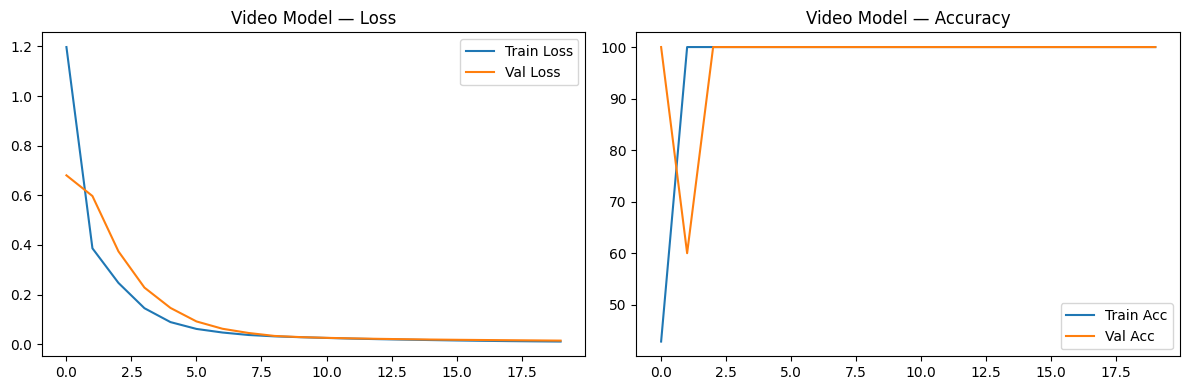

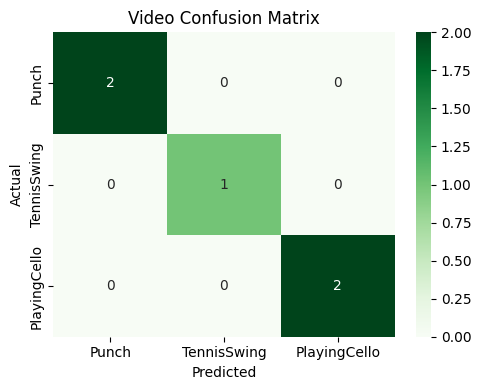

In [27]:

if len(X_video_feats) >= 6:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(video_history.history["loss"], label="Train Loss")
    axes[0].plot(video_history.history["val_loss"], label="Val Loss")
    axes[0].set_title("Video Model — Loss"); axes[0].legend()

    axes[1].plot(np.array(video_history.history["accuracy"]) * 100, label="Train Acc")
    axes[1].plot(np.array(video_history.history["val_accuracy"]) * 100, label="Val Acc")
    axes[1].set_title("Video Model — Accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("plot8_video_curves.png", dpi=150)
    plt.show()

    cm_video = confusion_matrix(yv_te, y_pred_video, labels=list(range(len(CLASSES))))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_video, annot=True, fmt="d", cmap="Greens",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title("Video Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig("plot9_video_confusion.png", dpi=150)
    plt.show()
else:
    print("Skipped — no trained video model available.")


## 20. Sequence-to-Sequence Learning — Synthetic Reversal Task

In [28]:

SEQ_LEN_S2S = 6
VOCAB_MIN, VOCAB_MAX = 1, 9  # single-digit integers
N_SAMPLES_S2S = 8000

def generate_reversal_data(n_samples, seq_len, vmin, vmax):
    X = np.random.randint(vmin, vmax + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_s2s, Y_s2s = generate_reversal_data(N_SAMPLES_S2S, SEQ_LEN_S2S, VOCAB_MIN, VOCAB_MAX)

# Reserve 0 as a start-of-sequence token for the decoder input
START_TOKEN = 0
VOCAB_SIZE = VOCAB_MAX + 1  # 0..9

decoder_input = np.concatenate(
    [np.full((N_SAMPLES_S2S, 1), START_TOKEN), Y_s2s[:, :-1]], axis=1
)

X_tr_s2s, X_te_s2s, Y_tr_s2s, Y_te_s2s, dec_in_tr, dec_in_te = train_test_split(
    X_s2s, Y_s2s, decoder_input, test_size=0.2, random_state=SEED
)

print("Encoder input example :", X_tr_s2s[0])
print("Target output example :", Y_tr_s2s[0])
print("Decoder input example :", dec_in_tr[0])


Encoder input example : [1 2 7 7 6 5]
Target output example : [5 6 7 7 2 1]
Decoder input example : [0 5 6 7 7 2]


## 21. Encoder–Decoder Model: Build and Train

In [29]:

LATENT_DIM = 64

# Encoder
enc_inputs = Input(shape=(SEQ_LEN_S2S,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, 32)(enc_inputs)
_, state_h, state_c = layers.LSTM(LATENT_DIM, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder (teacher forcing during training)
dec_inputs = Input(shape=(SEQ_LEN_S2S,), name="decoder_input")
dec_emb = layers.Embedding(VOCAB_SIZE, 32)(dec_inputs)
dec_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

s2s_history = seq2seq_model.fit(
    [X_tr_s2s, dec_in_tr], Y_tr_s2s,
    validation_split=0.15, epochs=30, batch_size=64, verbose=1
)


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 6, 32)     │        320 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 6, 32)     │        320 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 64),      │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 6, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm_5[0][1],     │
│                     │ (None, 64)]       │            │ lstm_5[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 6, 10)     │        650 │ lstm_6[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,954 (199.04 KB)

 Trainable params: 50,954 (199.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.2619 - loss: 2.0292 - val_accuracy: 0.3707 - val_loss: 1.6711
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5725 - loss: 1.1767 - val_accuracy: 0.7856 - val_loss: 0.7485
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8702 - loss: 0.5291 - val_accuracy: 0.9304 - val_loss: 0.3729
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9540 - loss: 0.2911 - val_accuracy: 0.9668 - val_loss: 0.2316
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9759 - loss: 0.1904 - val_accuracy: 0.9845 - val_loss: 0.1537
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9877 - loss: 0.1329 - val_accuracy: 0.9918 - val_loss: 0.1097
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9914 - loss: 0.1023 - val_accuracy: 0.9955 - val_loss: 0.0870
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9940 - loss: 0.0809 - val_accuracy: 0.9951 - val_l

## 22. Seq2Seq Inference (Greedy Decoding) and Evaluation

In [31]:
# Build standalone encoder and decoder for step-by-step inference
encoder_model = Model(enc_inputs, encoder_states)

dec_state_h_in = Input(shape=(LATENT_DIM,))
dec_state_c_in = Input(shape=(LATENT_DIM,))
dec_single_input = Input(shape=(1,))
dec_single_emb = layers.Embedding(VOCAB_SIZE, 32)(dec_single_input)
dec_single_out, dec_h, dec_c = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_out = dec_dense(dec_single_out)
decoder_model = Model([dec_single_input, dec_state_h_in, dec_state_c_in],
                       [dec_single_out, dec_h, dec_c])

def predict_sequence_batch(input_batch):
    # input_batch: (B, SEQ_LEN_S2S) -> greedy-decodes the whole batch at once
    h, c = encoder_model(input_batch, training=False)
    target = tf.fill([input_batch.shape[0], 1], START_TOKEN)
    outputs = []
    for _ in range(SEQ_LEN_S2S):
        out_probs, h, c = decoder_model([target, h, c], training=False)
        next_token = tf.argmax(out_probs[:, -1, :], axis=-1, output_type=tf.int32)
        outputs.append(next_token.numpy())
        target = next_token[:, None]
    return np.stack(outputs, axis=1)  # (B, SEQ_LEN_S2S)

# Run in batches instead of one sample at a time
BATCH_EVAL = 256
all_preds = []
for start in range(0, len(X_te_s2s), BATCH_EVAL):
    batch = tf.constant(X_te_s2s[start:start + BATCH_EVAL])
    all_preds.append(predict_sequence_batch(batch))
all_preds = np.concatenate(all_preds, axis=0)

correct_tokens = np.sum(all_preds == Y_te_s2s)
total_tokens = Y_te_s2s.size
correct_seqs = np.sum(np.all(all_preds == Y_te_s2s, axis=1))

token_accuracy = correct_tokens / total_tokens
sequence_accuracy = correct_seqs / len(X_te_s2s)

print(f"Token accuracy    : {token_accuracy:.4f}")
print(f"Sequence accuracy : {sequence_accuracy:.4f}")
print(f"Final training loss  : {s2s_history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {s2s_history.history['val_loss'][-1]:.4f}")

print("\nSample predictions:")
for i in range(5):
    print(f"{i+1}. Input: {X_te_s2s[i].tolist()}  ->  Predicted: {all_preds[i].tolist()}")

Token accuracy    : 0.2916
Sequence accuracy : 0.0000
Final training loss  : 0.0051
Final validation loss: 0.0087

Sample predictions:
1. Input: [6, 8, 9, 1, 9, 2]  ->  Predicted: [2, 2, 2, 2, 1, 1]
2. Input: [1, 9, 4, 9, 2, 7]  ->  Predicted: [7, 2, 2, 2, 2, 2]
3. Input: [4, 4, 2, 3, 8, 9]  ->  Predicted: [9, 9, 9, 9, 9, 9]
4. Input: [6, 9, 9, 6, 2, 9]  ->  Predicted: [9, 9, 9, 9, 9, 9]
5. Input: [9, 2, 1, 8, 3, 7]  ->  Predicted: [7, 7, 7, 7, 2, 2]


## 23. Consolidated Results Table

In [32]:

consolidated = pd.DataFrame({
    "RNN": {"Accuracy": rnn_eval["Accuracy (%)"], "Precision": rnn_eval["Macro Precision (%)"],
            "Recall": rnn_eval["Macro Recall (%)"], "F1": rnn_eval["Macro F1 (%)"],
            "Parameters": rnn_eval["Parameters"]},
    "LSTM": {"Accuracy": lstm_eval["Accuracy (%)"], "Precision": lstm_eval["Macro Precision (%)"],
             "Recall": lstm_eval["Macro Recall (%)"], "F1": lstm_eval["Macro F1 (%)"],
             "Parameters": lstm_eval["Parameters"]},
    "GRU": {"Accuracy": gru_eval["Accuracy (%)"], "Precision": gru_eval["Macro Precision (%)"],
            "Recall": gru_eval["Macro Recall (%)"], "F1": gru_eval["Macro F1 (%)"],
            "Parameters": gru_eval["Parameters"]},
}).T
print("Sequence classification (HAR):\n", consolidated.round(2))

if len(X_video_feats) >= 6:
    video_acc = accuracy_score(yv_te, y_pred_video) * 100
    video_prec = precision_score(yv_te, y_pred_video, average="macro", zero_division=0) * 100
    video_rec = recall_score(yv_te, y_pred_video, average="macro", zero_division=0) * 100
    video_f1 = f1_score(yv_te, y_pred_video, average="macro", zero_division=0) * 100
    print(f"\nCNN-LSTM (video): Accuracy={video_acc:.2f}%  Precision={video_prec:.2f}%  "
          f"Recall={video_rec:.2f}%  F1={video_f1:.2f}%  Params={video_model.count_params()}")

s2s_table = pd.DataFrame({
    "Metric": ["Token Accuracy", "Sequence Accuracy", "Final Train Loss", "Final Val Loss"],
    "Value": [token_accuracy, sequence_accuracy,
              s2s_history.history['loss'][-1], s2s_history.history['val_loss'][-1]]
})
print("\nSeq2Seq (reversal task):\n", s2s_table)


Sequence classification (HAR):
       Accuracy  Precision  Recall     F1  Parameters
RNN      66.86      66.30   65.91  65.04      1974.0
LSTM     87.86      88.23   88.26  88.20      6006.0
GRU      88.86      88.97   89.22  88.99      4758.0

CNN-LSTM (video): Accuracy=100.00%  Precision=100.00%  Recall=100.00%  F1=100.00%  Params=168163

Seq2Seq (reversal task):
               Metric     Value
0     Token Accuracy  0.291563
1  Sequence Accuracy  0.000000
2   Final Train Loss  0.005058
3     Final Val Loss  0.008697
